In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv


In [2]:
# Importando a base de dados
df = pd.read_csv('/kaggle/input/datasets/blastchar/telco-customer-churn/WA_Fn-UseC_-Telco-Customer-Churn.csv')

# Dicionário para altear o nome das colunas para PT-BR
dicionario_colunas = {
    'customerID': 'id_cliente',
    'gender': 'genero',
    'SeniorCitizen': 'idoso',
    'Partner': 'tem_parceiro',
    'Dependents': 'dependentes',
    'tenure': 'meses_contrato',
    'PhoneService': 'servico_telefone',
    'MultipleLines': 'multiplas_linhas',
    'InternetService': 'provedor_internet',
    'OnlineSecurity': 'seguranca_online',
    'OnlineBackup': 'backup_online',
    'DeviceProtection': 'protecao_dispositivo',
    'TechSupport': 'suporte_tecnico',
    'StreamingTV': 'tv_streaming',
    'StreamingMovies': 'filmes_streaming',
    'Contract': 'tipo_contrato',
    'PaperlessBilling': 'fatura_digital',
    'PaymentMethod': 'forma_pagamento',
    'MonthlyCharges': 'valor_mensal',
    'TotalCharges': 'valor_total',
    'Churn': 'cancelou'
}

# Alterando o nome das colunas para PT-BR baseado no dicionário
df = df.rename(columns = dicionario_colunas)

# O valor total (pago acumulado pelo cliente) estava como objeto, aqui converto para número
df['valor_total'] = pd.to_numeric(df['valor_total'], errors='coerce')

# Preencho com zero os valores vazios pois o cliente ainda não encerrou a fatura e não houve pagamento à empresa
df['valor_total'] = df['valor_total'].fillna(0)

# Convertendo a coluna cancelou para 0 e 1

dic_dummy = {
    'Yes': 1,
    'No': 0
}

# Convertando a coluna Idoso para Yes e No, mantendo o padrão das demais
dic_dummy_inverse = {
    1: 'Yes',
    0: 'No'
}

# Ajustando as colunas 
df['cancelou'] = df['cancelou'].map(dic_dummy)
df['idoso'] = df['idoso'].map(dic_dummy_inverse)

# Checando o formato dos dados
df.info()

display(df)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id_cliente            7043 non-null   object 
 1   genero                7043 non-null   object 
 2   idoso                 7043 non-null   object 
 3   tem_parceiro          7043 non-null   object 
 4   dependentes           7043 non-null   object 
 5   meses_contrato        7043 non-null   int64  
 6   servico_telefone      7043 non-null   object 
 7   multiplas_linhas      7043 non-null   object 
 8   provedor_internet     7043 non-null   object 
 9   seguranca_online      7043 non-null   object 
 10  backup_online         7043 non-null   object 
 11  protecao_dispositivo  7043 non-null   object 
 12  suporte_tecnico       7043 non-null   object 
 13  tv_streaming          7043 non-null   object 
 14  filmes_streaming      7043 non-null   object 
 15  tipo_contrato        

,id_cliente,genero,idoso,tem_parceiro,dependentes,meses_contrato,servico_telefone,multiplas_linhas,provedor_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,tv_streaming,filmes_streaming,tipo_contrato,fatura_digital,forma_pagamento,valor_mensal,valor_total,cancelou
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,No,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,2234-XADUH,Female,No,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,Yes,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [3]:
# Criando a lógica para analisar a Taxa de Churn e Frequência Relativa da Categoria

tabela_idoso = pd.crosstab(df['idoso'], df['cancelou']).reset_index()
tabela_idoso.columns = ['Idoso', 'Não Cancelou', 'Cancelou']
qtd_grupo = tabela_idoso['Cancelou'] + tabela_idoso['Não Cancelou']
tabela_idoso['Freq. Relativa'] = qtd_grupo / qtd_grupo.sum()
tabela_idoso['Taxa de Churn'] = tabela_idoso['Cancelou'] / (tabela_idoso['Cancelou'] + tabela_idoso['Não Cancelou'] )
tabela_form = tabela_idoso.style.format(
    {'Taxa de Churn': '{:.2%}',
    'Freq. Relativa': '{:.2%}'})
display(tabela_form)


,Idoso,Não Cancelou,Cancelou,Freq. Relativa,Taxa de Churn
0,No,4508,1393,83.79%,23.61%
1,Yes,666,476,16.21%,41.68%


In [4]:
# Criar função para analisar cada variável Categórica 

def analisar_churn (df, coluna_analisada, coluna_churn='cancelou'):
    
    tabela = pd.crosstab(df[coluna_analisada], df[coluna_churn]).reset_index()

    # Renomeia as colunas
    tabela.columns = [coluna_analisada, 'Não Cancelou', 'Cancelou']

    # Cria a Frequência Relativa e a Taxa de Churn
    qtd_grupo = tabela['Cancelou'] + tabela['Não Cancelou']
    tabela['Freq. Relativa'] = qtd_grupo / qtd_grupo.sum()
    tabela['Taxa de Churn'] = tabela['Cancelou'] / (tabela['Cancelou'] + tabela['Não Cancelou'])

    # Formata apenas o visual em %
    tabela_formatada = tabela.style.format({
        'Taxa de Churn': '{:.2%}',
        'Freq. Relativa': '{:.2%}'
    }).background_gradient(cmap='YlOrRd', subset=['Taxa de Churn'])
    
    return tabela_formatada


In [5]:
colunas_categoricas = ['genero', 'idoso', 'tem_parceiro', 'dependentes', 'servico_telefone', 'multiplas_linhas', 'provedor_internet', 'seguranca_online', 'backup_online', 'protecao_dispositivo',
 'suporte_tecnico', 'tv_streaming', 'filmes_streaming', 'tipo_contrato', 'fatura_digital', 'forma_pagamento']


for col in colunas_categoricas:
    print(f"=== ANÁLISE DE CHURN: {col.upper()} ===")

    # Chamando a função
    tabela_resultado = analisar_churn(df, col)

    # Exibir a tabela resultado
    display(tabela_resultado) 

=== ANÁLISE DE CHURN: GENERO ===


,genero,Não Cancelou,Cancelou,Freq. Relativa,Taxa de Churn
0,Female,2549,939,49.52%,26.92%
1,Male,2625,930,50.48%,26.16%


=== ANÁLISE DE CHURN: IDOSO ===


,idoso,Não Cancelou,Cancelou,Freq. Relativa,Taxa de Churn
0,No,4508,1393,83.79%,23.61%
1,Yes,666,476,16.21%,41.68%


=== ANÁLISE DE CHURN: TEM_PARCEIRO ===


...

,tipo_contrato,Não Cancelou,Cancelou,Freq. Relativa,Taxa de Churn
0,Month-to-month,2220,1655,55.02%,42.71%
1,One year,1307,166,20.91%,11.27%
2,Two year,1647,48,24.07%,2.83%


=== ANÁLISE DE CHURN: FATURA_DIGITAL ===


,fatura_digital,Não Cancelou,Cancelou,Freq. Relativa,Taxa de Churn
0,No,2403,469,40.78%,16.33%
1,Yes,2771,1400,59.22%,33.57%


=== ANÁLISE DE CHURN: FORMA_PAGAMENTO ===


,forma_pagamento,Não Cancelou,Cancelou,Freq. Relativa,Taxa de Churn
0,Bank transfer (automatic),1286,258,21.92%,16.71%
1,Credit card (automatic),1290,232,21.61%,15.24%
2,Electronic check,1294,1071,33.58%,45.29%
3,Mailed check,1304,308,22.89%,19.11%


In [6]:
# Criando a lógica para analisar o IV (information Value) de uma Categoria
# Existem bibliotecas que calcula o IV de forma automática, mas aqui eu quis praticar e aplicar o conceito

tabela_idoso = pd.crosstab(df['idoso'], df['cancelou']).reset_index()
tabela_idoso.columns = ['Idoso', 'Não Cancelou', 'Cancelou',]
qtd_grupo = tabela_idoso['Cancelou'] + tabela_idoso['Não Cancelou']
tabela_idoso['Freq. Relativa'] = qtd_grupo / qtd_grupo.sum()
tabela_idoso['Taxa de Churn'] = tabela_idoso['Cancelou'] / (tabela_idoso['Cancelou'] + tabela_idoso['Não Cancelou'] )
tabela_idoso['Freq. Total'] = qtd_grupo.sum()
tabela_idoso['Qtd Bons'] = tabela_idoso['Não Cancelou'].sum()
tabela_idoso['Qtd Maus'] = tabela_idoso['Cancelou'].sum()
tabela_idoso['% Bons'] = tabela_idoso['Não Cancelou'] / tabela_idoso['Qtd Bons']
tabela_idoso['% Maus'] = tabela_idoso['Cancelou'] / tabela_idoso['Qtd Maus']
tabela_idoso['% Taxa de Bons'] = tabela_idoso['Não Cancelou'] / (tabela_idoso['Não Cancelou'] + tabela_idoso['Cancelou'])
tabela_idoso['Odds'] = tabela_idoso['% Bons'] / tabela_idoso['% Maus']
tabela_idoso['LN (Odds)'] = np.log(tabela_idoso['Odds'])
tabela_idoso['IV'] = (tabela_idoso['% Bons'] - tabela_idoso['% Maus']) * tabela_idoso['LN (Odds)']
tabela_idoso['IV Total'] = tabela_idoso['IV'].sum()
tabela_form = tabela_idoso.style.format(
    {'Taxa de Churn': '{:.2%}',
    'Freq. Relativa': '{:.2%}',
    'IV': '{:.2}',
     'IV Total': '{:.2}'
})
display(tabela_form)

,Idoso,Não Cancelou,Cancelou,Freq. Relativa,Taxa de Churn,Freq. Total,Qtd Bons,Qtd Maus,% Bons,% Maus,% Taxa de Bons,Odds,LN (Odds),IV,IV Total
0,No,4508,1393,83.79%,23.61%,7043,5174,1869,0.871279,0.745318,0.763938,1.169003,0.156151,0.02,0.11
1,Yes,666,476,16.21%,41.68%,7043,5174,1869,0.128721,0.254682,0.583187,0.505417,-0.682371,0.086,0.11


In [7]:
'''
Regra geral para interpretar o resultado do IV:
< 0.02: Indescritível / Sem poder de separação.
0.02 a 0.1: Poder fraco.
0.1 a 0.3: Poder médio.
0.3 a 0.5: Poder forte.
> 0.5: Suspeito / Forte demais (pode ser vazamento de dados). 
'''
# Esta função retorna a tabela completa do IV
def tabela_IV (df, coluna_analisada, coluna_churn='cancelou'):
    tabela = pd.crosstab(df[coluna_analisada], df[coluna_churn]).reset_index()
    tabela.columns = [coluna_analisada, 'Não Cancelou', 'Cancelou',]
    qtd_grupo = tabela['Cancelou'] + tabela['Não Cancelou']
    tabela['Freq. Relativa'] = qtd_grupo / qtd_grupo.sum()
    tabela['Taxa de Churn'] = tabela['Cancelou'] / (tabela['Cancelou'] + tabela['Não Cancelou'] )
    tabela['Freq. Total'] = qtd_grupo.sum()
    tabela['Qtd Bons'] = tabela['Não Cancelou'].sum()
    tabela['Qtd Maus'] = tabela['Cancelou'].sum()
    tabela['% Bons'] = tabela['Não Cancelou'] / tabela['Qtd Bons']
    tabela['% Maus'] = tabela['Cancelou'] / tabela['Qtd Maus']
    tabela['% Taxa de Bons'] = tabela['Não Cancelou'] / (tabela['Não Cancelou'] + tabela['Cancelou'])
    tabela['Odds'] = tabela['% Bons'] / tabela['% Maus']
    tabela['LN (Odds)'] = np.log(tabela['Odds'])
    tabela['IV'] = (tabela['% Bons'] - tabela['% Maus']) * tabela['LN (Odds)']
    tabela['IV Total'] = tabela['IV'].sum()
    tabela_form = tabela.style.format(
        {'Taxa de Churn': '{:.2%}',
        'Freq. Relativa': '{:.2%}',
        'IV': '{:.2}',
         'IV Total': '{:.2}'
    })
    return tabela_form
    #return tabela['IV Total']

In [8]:
resultado = tabela_IV(df, 'genero')
display(resultado)

,genero,Não Cancelou,Cancelou,Freq. Relativa,Taxa de Churn,Freq. Total,Qtd Bons,Qtd Maus,% Bons,% Maus,% Taxa de Bons,Odds,LN (Odds),IV,IV Total
0,Female,2549,939,49.52%,26.92%,7043,5174,1869,0.492656,0.502408,0.730791,0.980589,-0.019602,0.00019,0.00038
1,Male,2625,930,50.48%,26.16%,7043,5174,1869,0.507344,0.497592,0.738397,1.019599,0.019409,0.00019,0.00038


In [9]:
'''
Regra geral para interpretar o resultado do IV:
< 0.02: Indescritível / Sem poder de separação.
0.02 a 0.1: Poder fraco.
0.1 a 0.3: Poder médio.
0.3 a 0.5: Poder forte.
> 0.5: Suspeito / Forte demais (pode ser vazamento de dados). 
'''
# Esta função retorna somente o IV
def calcular_IV (df, coluna_analisada, coluna_churn='cancelou'):
    tabela = pd.crosstab(df[coluna_analisada], df[coluna_churn]).reset_index()
    tabela.columns = [coluna_analisada, 'Não Cancelou', 'Cancelou',]
    qtd_grupo = tabela['Cancelou'] + tabela['Não Cancelou']
    tabela['Freq. Relativa'] = qtd_grupo / qtd_grupo.sum()
    tabela['Taxa de Churn'] = tabela['Cancelou'] / (tabela['Cancelou'] + tabela['Não Cancelou'] )
    tabela['Freq. Total'] = qtd_grupo.sum()
    tabela['Qtd Bons'] = tabela['Não Cancelou'].sum()
    tabela['Qtd Maus'] = tabela['Cancelou'].sum()
    tabela['% Bons'] = tabela['Não Cancelou'] / tabela['Qtd Bons']
    tabela['% Maus'] = tabela['Cancelou'] / tabela['Qtd Maus']
    tabela['% Taxa de Bons'] = tabela['Não Cancelou'] / (tabela['Não Cancelou'] + tabela['Cancelou'])
    tabela['Odds'] = tabela['% Bons'] / tabela['% Maus']
    tabela['LN (Odds)'] = np.log(tabela['Odds'])
    tabela['IV'] = (tabela['% Bons'] - tabela['% Maus']) * tabela['LN (Odds)']
    tabela['IV Total'] = tabela['IV'].sum()
    iv_final = tabela['IV Total'].iloc[0]
       
    return round(iv_final, 4)

In [10]:
colunas_categoricas = ['genero', 'idoso', 'tem_parceiro', 'dependentes', 'servico_telefone', 'multiplas_linhas', 'provedor_internet', 'seguranca_online', 'backup_online', 'protecao_dispositivo',
 'suporte_tecnico', 'tv_streaming', 'filmes_streaming', 'tipo_contrato', 'fatura_digital', 'forma_pagamento']

resultados_iv = {}

for col in colunas_categoricas:
    iv_calculado = calcular_IV(df, col)
    resultados_iv[col] = float(iv_calculado)

df_iv = pd.DataFrame(list(resultados_iv.items()), columns=['Variável', 'IV Total'])

df_iv = df_iv.sort_values(by='IV Total', ascending=False).reset_index(drop=True)

condicoes = [
    df_iv['IV Total'] < 0.02,
    (df_iv['IV Total'] >= 0.02) & (df_iv['IV Total'] < 0.10),
    (df_iv['IV Total'] >= 0.10) & (df_iv['IV Total'] < 0.30),
    (df_iv['IV Total'] >= 0.30) & (df_iv['IV Total'] <= 0.50),
    df_iv['IV Total'] > 0.50
]

classificacoes = [
    'Inútil / Sem Poder',
    'Poder Fraco',
    'Poder Médio',
    'Poder Forte',
    'Suspeito / Muito Forte (Overfitting)'
]

df_iv['Poder Preditivo'] = np.select(condicoes, classificacoes, default='Não Classificado')

display(df_iv.style.format({'IV Total': '{:.4f}'}))


,Variável,IV Total,Poder Preditivo
0,tipo_contrato,1.2386,Suspeito / Muito Forte (Overfitting)
1,seguranca_online,0.7178,Suspeito / Muito Forte (Overfitting)
2,suporte_tecnico,0.6996,Suspeito / Muito Forte (Overfitting)
3,provedor_internet,0.6180,Suspeito / Muito Forte (Overfitting)
4,backup_online,0.5286,Suspeito / Muito Forte (Overfitting)
5,protecao_dispositivo,0.4997,Poder Forte
6,forma_pagamento,0.4571,Poder Forte
7,filmes_streaming,0.3814,Poder Forte
8,tv_streaming,0.3805,Poder Forte
9,fatura_digital,0.2031,Poder Médio


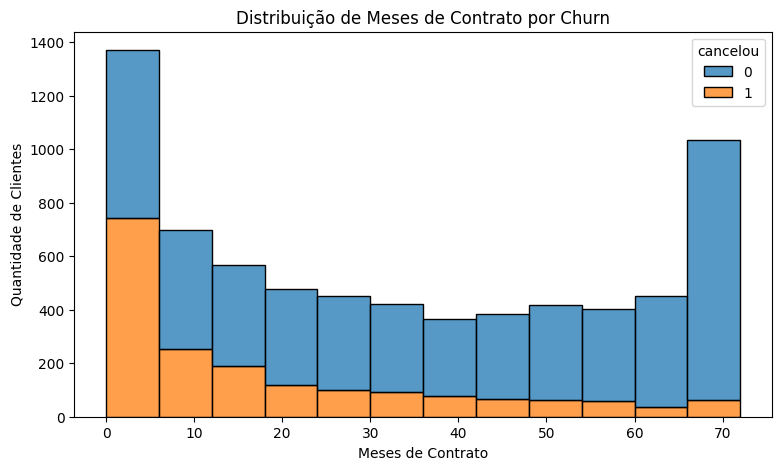

In [11]:
colunas_numericas = ['meses_contrato', 'valor_mensal', 'valor_total']

plt.figure(figsize=(9, 5))
# O parâmetro 'hue' divide as barras entre quem cancelou e quem não cancelou
sns.histplot(data=df, x='meses_contrato', hue='cancelou', bins=12, multiple='stack')
plt.title('Distribuição de Meses de Contrato por Churn')
plt.xlabel('Meses de Contrato')
plt.ylabel('Quantidade de Clientes')
plt.show()

In [12]:
# Verificando a curva de sobrevivência

# Aqui eu crio a faixa de meses, como são 72 meses, eu divido em 6 slots para ficar um ano em cada.
df['faixa_meses'] = pd.cut(df['meses_contrato'], bins=6, precision=0)

# Agrupando por faixa de meses e criando Taxa de Churn
df_tempo_churn = df.groupby('faixa_meses', observed=False).agg(
    total_clientes=('cancelou', 'count'),
    cancelou=('cancelou', 'sum'),
    Taxa_Churn=('cancelou', 'mean')
).reset_index()

# Formatando o visual para a variável se manter numérica
df_tempo_churn_formatado = df_tempo_churn.style.format({
    'Taxa_Churn': '{:.2%}'
}).background_gradient(cmap='YlOrRd', subset=['Taxa_Churn'])

# Exibindo a tabela
display(df_tempo_churn_formatado)

,faixa_meses,total_clientes,cancelou,Taxa_Churn
0,"(-0.1, 12.0]",2186,1037,47.44%
1,"(12.0, 24.0]",1024,294,28.71%
2,"(24.0, 36.0]",832,180,21.63%
3,"(36.0, 48.0]",762,145,19.03%
4,"(48.0, 60.0]",832,120,14.42%
5,"(60.0, 72.0]",1407,93,6.61%


In [13]:
# Como o maior número de cancelamentos é no primeiro ano, irei detalhar o primeiro ano em trimestre
df_primeiro_ano = df[df['meses_contrato'] <=12 ].copy()

# Criando a Faixa de Trimestre
df_primeiro_ano['Trimestre'] = pd.cut(
    df_primeiro_ano['meses_contrato'],
    bins=[0, 3, 6, 9, 12],
    labels=['0 a 3 meses', '3 a 6 meses', '6 a 9 meses', '9 a 12 meses'],
    include_lowest=True)

# Agrupando por faixa de trimestre e criando Taxa de Churn
df_trimestral = df_primeiro_ano.groupby('Trimestre', observed=False).agg(
    total_clientes=('cancelou', 'count'),
    cancelou=('cancelou', 'sum'),
    Taxa_Churn=('cancelou', 'mean')
).reset_index()

df_trimestral_formatado = df_trimestral.style.format({
    'Taxa_Churn': '{:.2%}'
}).background_gradient(cmap='YlOrRd', subset=['Taxa_Churn'])

display(df_trimestral_formatado)

,Trimestre,total_clientes,cancelou,Taxa_Churn
0,0 a 3 meses,1062,597,56.21%
1,3 a 6 meses,419,187,44.63%
2,6 a 9 meses,373,139,37.27%
3,9 a 12 meses,332,114,34.34%


In [14]:
df_ticket = df[['valor_mensal', 'cancelou', 'provedor_internet']].copy()

# Avaliando os itens que possuem o maior IV (information value x MRR perdido)
# MRR: Monthly Recurring Revenue (Receita Recorrente Mensal) dos clientes que cancelaram

# Primeiro item avaliado: provedor_internet
# Criando três blocos de Ticket (baixo, médio e alto), conforme o valor mensal pago por cada cliente 
df_ticket['Ticket'] = pd.cut(
    df['valor_mensal'],
    bins=3,
    labels=['Baixo', 'Médio', 'Alto'],
    precision=0
)

# Calculando o MRR perdido (churn x valor mensal)
df_ticket['MRR Perdido'] = df_ticket['valor_mensal'] * df_ticket['cancelou']

# Criando dataframe que evidência a taxa de churne e o MRR perdido
df_ticket_medio = df_ticket.groupby(['Ticket', 'provedor_internet'], observed=False).agg(
    clientes=('cancelou', 'count'),
    cancelou=('cancelou', 'sum'),
    Taxa_Churn=('cancelou', 'mean'),
    MRR_perdido=('MRR Perdido', 'sum')
)

df_ticket_medio_formatado = df_ticket_medio.style.format({
    'Taxa_Churn': '{:.2%}',
    'MRR_perdido': '{:,.2f}'
}, thousands='.', decimal=',').bar(subset=['MRR_perdido'], color='#f8d7da', vmin=0).background_gradient(cmap='YlOrRd', subset=['Taxa_Churn'])

display(df_ticket_medio_formatado)

In [15]:
# Avaliando os itens que possuem o maior IV (information value x MRR perdido)
# MRR: Monthly Recurring Revenue (Receita Recorrente Mensal) dos clientes que cancelaram

def analisar_matriz_risco (coluna_servico):    
    df_temp = df[['valor_mensal', 'cancelou', coluna_servico]].copy()
    
    # Criando três blocos de Ticket (baixo, médio e alto), conforme o valor mensal pago por cada cliente 
    df_temp['Ticket'] = pd.cut(
        df['valor_mensal'],
        bins=3,
        labels=['Baixo', 'Médio', 'Alto'],
        precision=0
    )
    
    # Calculando o MRR perdido (churn x valor mensal)
    df_temp['MRR Perdido'] = df_temp['valor_mensal'] * df_temp['cancelou']

    
    # Criando dataframe que evidencia a taxa de churn e o MRR perdido.
    resumo = df_temp.groupby(['Ticket', coluna_servico], observed=False).agg(
        clientes=('cancelou', 'count'),
        cancelou=('cancelou', 'sum'),
        Taxa_Churn=('cancelou', 'mean'),
        MRR_perdido=('MRR Perdido', 'sum')        
    )
    
    return resumo.style.format({
        'Taxa_Churn': '{:.2%}',
        'MRR_perdido': '{:,.2f}'
    }, thousands='.', decimal=',').bar(subset=['MRR_perdido'], color='#f8d7da', vmin=0).background_gradient(cmap='YlOrRd', subset=['Taxa_Churn'])


display(analisar_matriz_risco('tipo_contrato')) # IV Top 1
display(analisar_matriz_risco('seguranca_online')) # IV Top 2
display(analisar_matriz_risco('provedor_internet')) # IV Top 4


Resumo
1. Em tipo de contrato, os maiores MRR perdidos estão em quem paga mês-a-mês, tanto em ticket médio quanto alto.
2. Em segurança online, os maiores MRR perdidos estão em quem não contrata o serviço..
3. Em provedor de internet, os maiores MRR perdidos estão em fibra optica.

Perfil do cliente que mais gera prejuízo:
1. Ele contrata Fibra Óptica (o que o joga nos tickets Médio e Alto).
2. Ele está em um contrato Mês a Mês (sem fidelidade/engajamento de longo prazo).
3. Ele não contrata Serviços Adicionais como Segurança Online.

In [16]:
# Análise de Cross-selling x Atrito de serviço

# 1. Lista com as 6 colunas de serviços adicionais
colunas_servicos = [
    'seguranca_online', 
    'suporte_tecnico', 
    'backup_online', 
    'protecao_dispositivo', 
    'tv_streaming', 
    'filmes_streaming'
]

df_qtd_servicos = df.copy()

# 2. Criando a coluna com a contagem de serviços (soma horizontal de 'Yes')
df_qtd_servicos['qtd_servicos'] = (df_qtd_servicos[colunas_servicos] == 'Yes').sum(axis=1)

df_tx_qtd_serv = df_qtd_servicos.groupby('qtd_servicos', observed=False).agg(
    clientes=('cancelou', 'count'),
    cancelou=('cancelou', 'sum'),
    Taxa_Churn=('cancelou', 'mean')
).reset_index()

df_form_serv = df_tx_qtd_serv.style.format({
    'Taxa_Churn': '{:.2%}'
}).background_gradient(cmap='YlOrRd', subset='Taxa_Churn')

display(df_form_serv)

,qtd_servicos,clientes,cancelou,Taxa_Churn
0,0,2219,475,21.41%
1,1,966,442,45.76%
2,2,1033,370,35.82%
3,3,1118,306,27.37%
4,4,852,190,22.30%
5,5,571,71,12.43%
6,6,284,15,5.28%


A Anomalia do "1 Serviço" (Ponto Crítico):

O maior Churn do negócio acontece quando o cliente contrata apenas 1 serviço adicional (45,76%).

Curiosamente, quem não tem nenhum serviço adicional (0) cancela bem menos (21,41%).
Isso sugere que a fricção ou a expectativa em relação ao primeiro serviço adicional pode estar gerando insatisfação imediata.

O Efeito Proteção do Cross-selling:
A partir do 2º serviço, a taxa de cancelamento cai de forma contínua: